Here, a Linear Regression model is implemented. Different scenarios are tested with the data and the model. I warmly encourage you to play with the data frame and test variations of the parameters. The result could be improved if the outliers are removed. This is another optimisation that you could test.

## 0. Import Data and Overview it

In [1]:
medical_charges_url = 'https://raw.githubusercontent.com/JovianML/opendatasets/master/data/medical-charges.csv'

In [2]:
from urllib.request import urlretrieve

urlretrieve(medical_charges_url, "data/medical.csv")        # Create data folder or just store the file medical.csv

('data/medical.csv', <http.client.HTTPMessage at 0x7fe18ed55a30>)

In [3]:
import pandas as pd

medical_df = pd.read_csv("data/medical.csv").convert_dtypes()

In [4]:
medical_df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.9,0,yes,southwest,16884.924
1,18,male,33.77,1,no,southeast,1725.5523
2,28,male,33.0,3,no,southeast,4449.462
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.88,0,no,northwest,3866.8552
...,...,...,...,...,...,...,...
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.8,0,no,southwest,2007.945


In [5]:
medical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   Int64  
 1   sex       1338 non-null   string 
 2   bmi       1338 non-null   Float64
 3   children  1338 non-null   Int64  
 4   smoker    1338 non-null   string 
 5   region    1338 non-null   string 
 6   charges   1338 non-null   Float64
dtypes: Float64(2), Int64(2), string(3)
memory usage: 78.5 KB


In [6]:
medical_df.describe()

,age,bmi,children,charges
count,1338.0,1338.0,1338.0,1338.0
mean,39.207025,30.663397,1.094918,13270.422265
std,14.04996,6.098187,1.205493,12110.011237
min,18.0,15.96,0.0,1121.8739
25%,27.0,26.29625,0.0,4740.28715
50%,39.0,30.4,1.0,9382.033
75%,51.0,34.69375,2.0,16639.912515
max,64.0,53.13,5.0,63770.42801


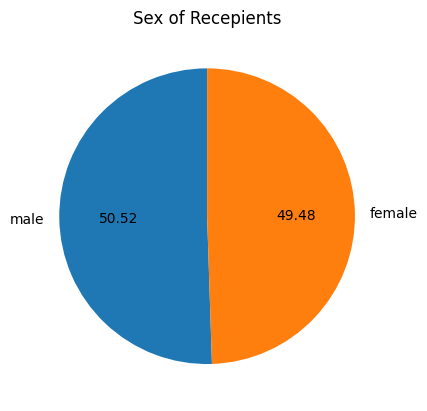

In [7]:
medical_df["sex"].value_counts().plot(kind = "pie", startangle = 90, autopct = "%1.2f",
                                      ylabel = "", title = "Sex of Recepients");

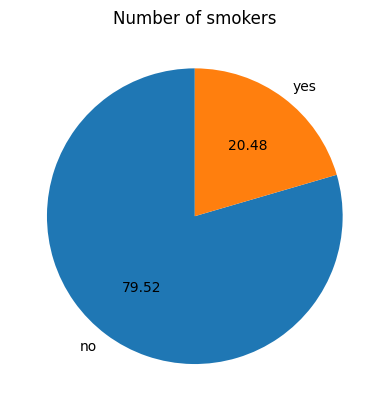

In [8]:
medical_df["smoker"].value_counts().plot(kind = "pie", startangle = 90, autopct = "%1.2f",
                                         ylabel = "", title = "Number of smokers");

<Axes: title={'center': 'Regions'}>

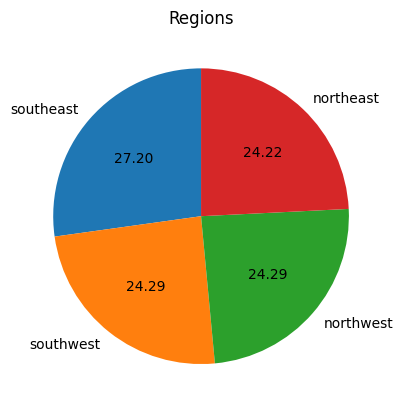

In [9]:
medical_df["region"].value_counts().plot(kind = "pie", startangle = 90, autopct = "%1.2f",
                                         ylabel = "", title = "Regions")

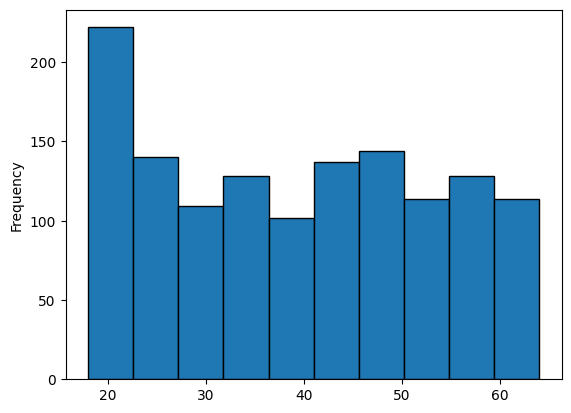

In [10]:
medical_df["age"].plot(kind = "hist", edgecolor = "black");

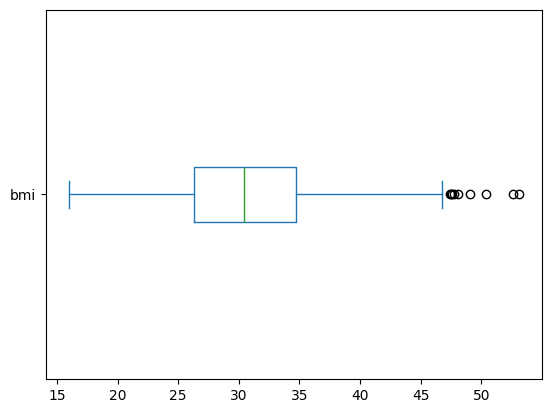

In [11]:
medical_df["bmi"].plot(kind = "box", vert = False);

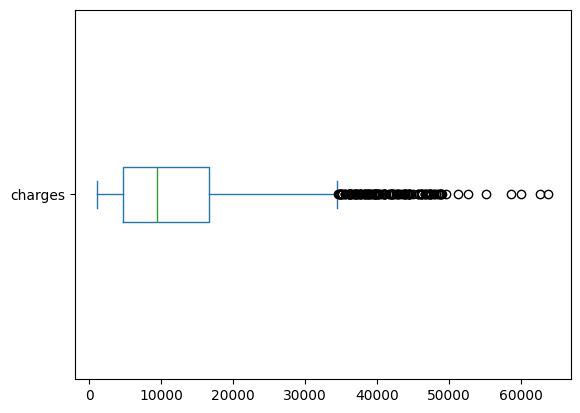

In [12]:
medical_df["charges"].plot(kind = "box", vert = False);

## 1. Analyze the Data with Plotly

In [13]:
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
# fig = px.histogram(medical_df, x = "age", marginal = "box", nbins = 47,
#                    title = "Distribution of Age")
# fig.update_layout(bargap = 0.1)
# fig.show()

In [15]:
# fig = px.histogram(medical_df, x = "bmi", marginal = "box", nbins = 47,
#                    color_discrete_sequence = ["red"], title = "Distribution of Age")
# fig.update_layout(bargap = 0.1)
# fig.show()

In [16]:
# fig = px.histogram(medical_df, x = "charges", marginal = "box", color = "smoker",
#                    color_discrete_sequence = ["green", "gray"], title = "Annual Medical Charges")
# fig.update_layout(bargap = 0.2)
# fig.show()

In [17]:
# fig = px.histogram(medical_df, x = "charges", marginal = "box", color = "sex",
#                    color_discrete_sequence = ["green", "gray"], title = "Annual Medical Charges")
# fig.update_layout(bargap = 0.2)
# fig.show()

In [18]:
# fig = px.histogram(medical_df, x = "charges", marginal = "box", color = "region",
#                    color_discrete_sequence = ["green", "gray", "yellow", "magenta"], title = "Annual Medical Charges")
# fig.update_layout(bargap = 0.2)
# fig.show()

In [19]:
# px.histogram(medical_df, x = "smoker", color = "sex", title = "Smokers")

In [20]:
# fig = px.scatter(medical_df, x = "age", y = "charges", color = "smoker",
#                  opacity = 0.8, hover_data= ["sex"], title = "Age vs Charges")
# fig.update_traces(marker_size = 5)
# fig.show()

In [21]:
# fig = px.scatter(medical_df, x = "bmi", y = "charges", color = "smoker",
#                  opacity = 0.8, hover_data= ["sex"], title = "BMI vs Charges")
# fig.update_traces(marker_size = 5)
# fig.show()

## 2. Detailed Analysis with Pandas Library

In [22]:
medical_df_age = medical_df.groupby(["age"])["charges"].agg(["min", "max", "median"])
#medical_df_age

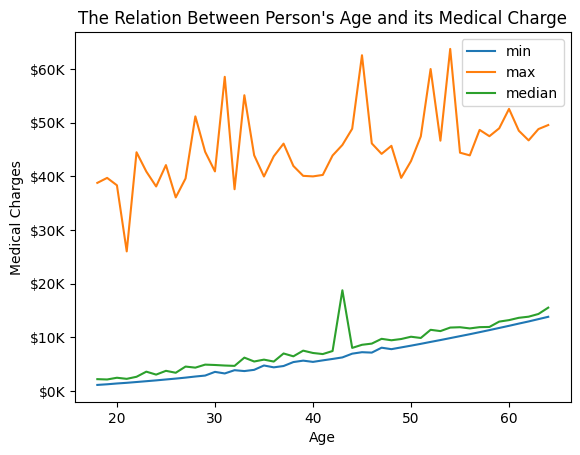

In [23]:
medical_df_age.plot(kind = "line")

plt.title("The Relation Between Person's Age and its Medical Charge")
plt.xlabel("Age")
plt.ylabel("Medical Charges")
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
plt.show()

In [24]:
medical_df_men = medical_df[medical_df["sex"] == "male"]
medical_df_women = medical_df[medical_df["sex"] == "female"]

In [25]:
medical_df_age_men = medical_df_men.groupby(["age"])["charges"].agg(["min", "max", "median"])
medical_df_age_women = medical_df_women.groupby(["age"])["charges"].agg(["min", "max", "median"])

In [26]:
medical_df_age_men.index

Index([18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
       36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53,
       54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64],
      dtype='Int64', name='age')

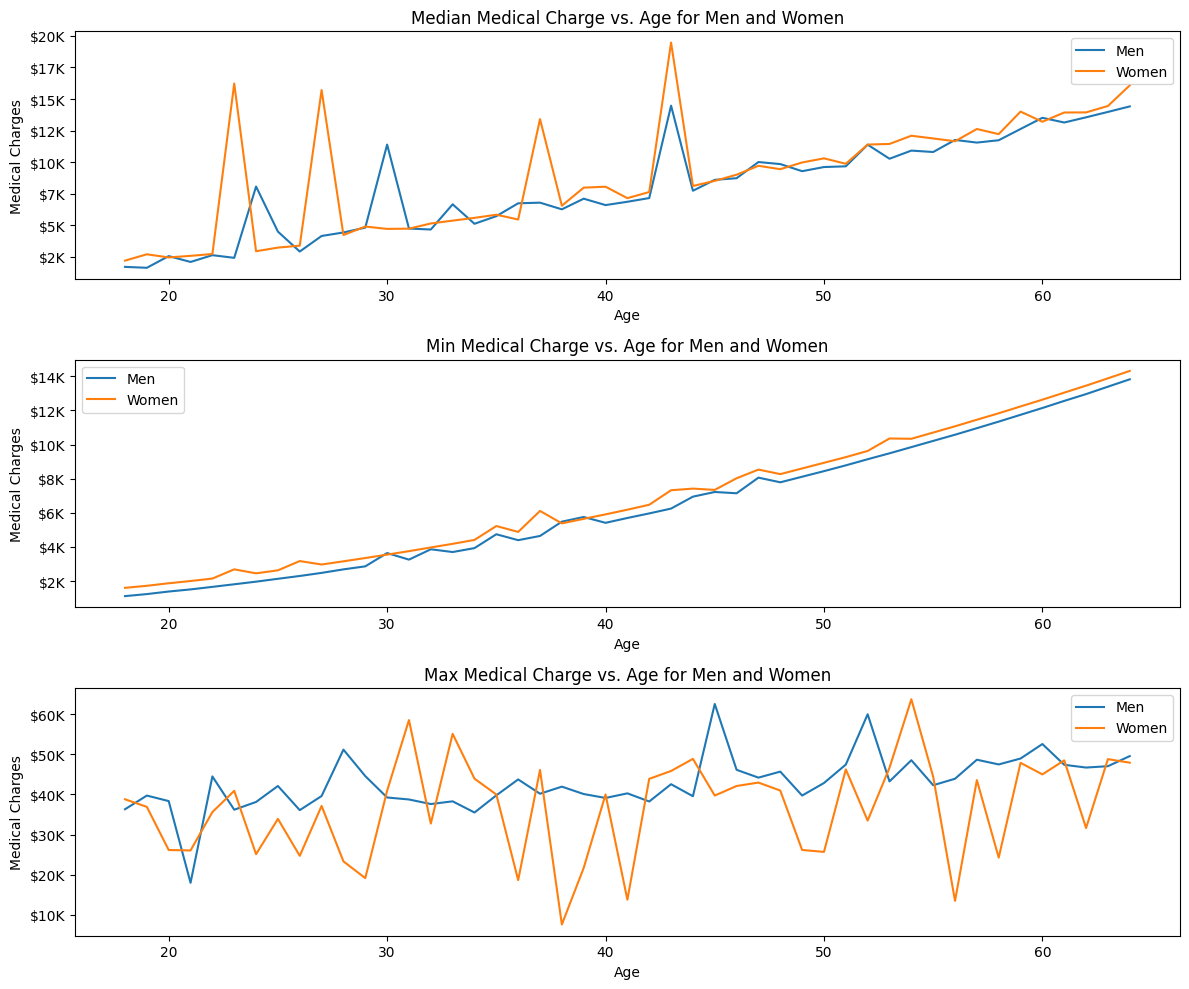

In [27]:
fig, ax = plt.subplots(3, 1, figsize=(12, 10))

metrics = [
    ("median", "Median Medical Charge vs. Age for Men and Women"),
    ("min", "Min Medical Charge vs. Age for Men and Women"),
    ("max", "Max Medical Charge vs. Age for Men and Women")
]

formatter = plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K')

for i, (metric, title) in enumerate(metrics):
    medical_df_age_men[metric].plot(kind="line", ax=ax[i], label="Men")
    medical_df_age_women[metric].plot(kind="line", ax=ax[i], label="Women")

    ax[i].set_title(title)
    ax[i].set_xlabel("Age")
    ax[i].set_ylabel("Medical Charges")
    ax[i].yaxis.set_major_formatter(formatter)
    ax[i].legend()

plt.tight_layout()
plt.show()

In [28]:
medical_df["children"].value_counts()

,count
children,
0,574
1,324
2,240
3,157
4,25
5,18


In [29]:
medical_df_children = medical_df.groupby(["children"])["charges"].agg(["min", "max", "median"])
medical_df_children

,min,max,median
children,,,
0,1121.8739,63770.42801,9856.9519
1,1711.0268,58571.07448,8483.87015
2,2304.0022,49577.6624,9264.97915
3,3443.064,60021.39897,10600.5483
4,4504.6624,40182.246,11033.6617
5,4687.797,19023.26,8589.56505


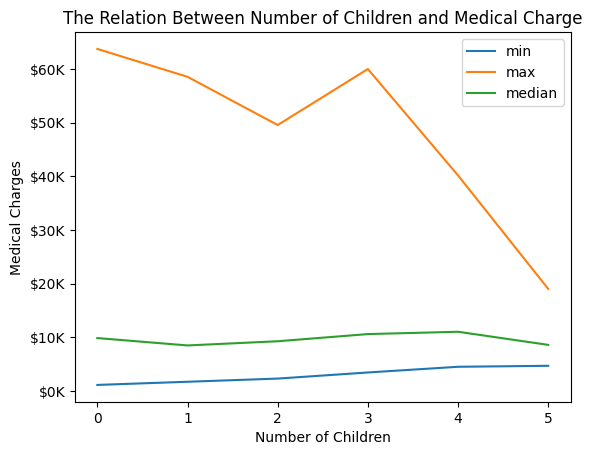

In [30]:
medical_df_children.plot(kind = "line")

plt.title("The Relation Between Number of Children and Medical Charge")
plt.xlabel("Number of Children")
plt.ylabel("Medical Charges")
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
plt.show()

In [31]:
df_region_pivot = pd.pivot_table(data = medical_df, values = "charges", index = "region", columns = "sex", aggfunc = "median")


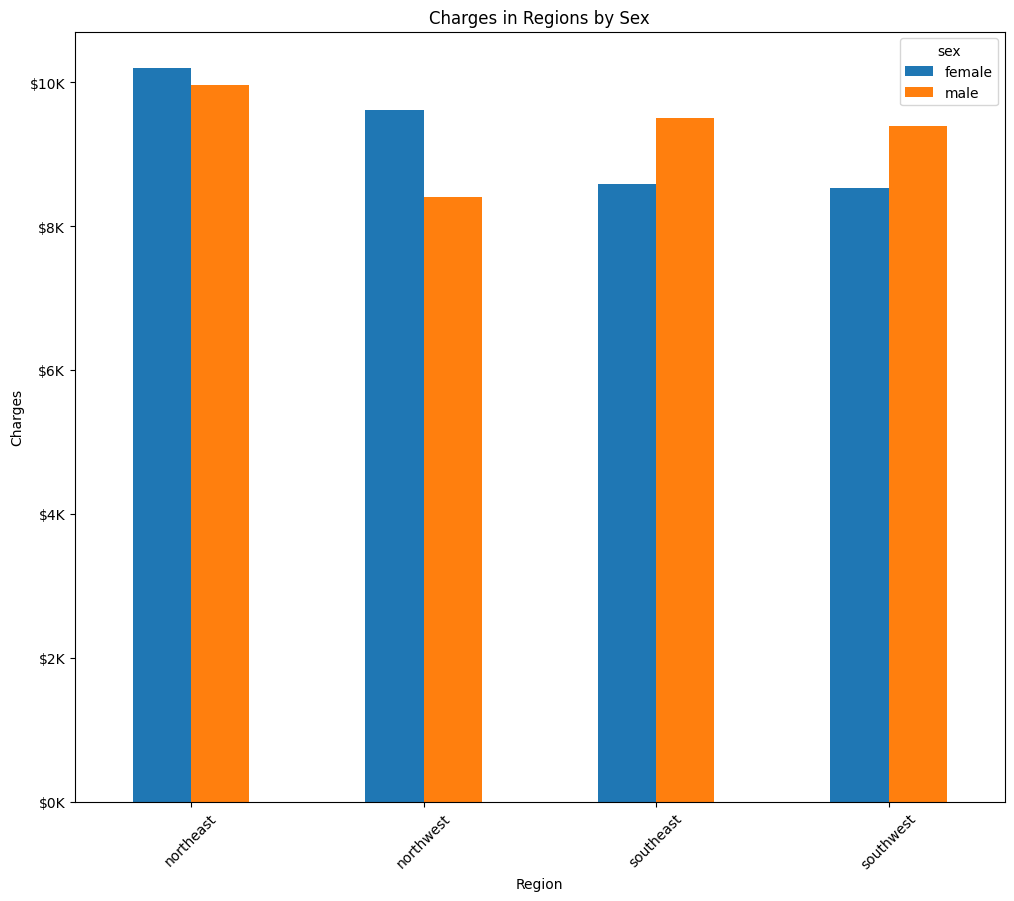

In [32]:
formatter = plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K')

df_region_pivot.plot(kind = "bar", rot = 45, figsize = (12, 10),
                      xlabel = "Region", ylabel = "Charges",
                      title = "Charges in Regions by Sex");
ax = plt.gca()
ax.yaxis.set_major_formatter(formatter)

In [33]:
medical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   Int64  
 1   sex       1338 non-null   string 
 2   bmi       1338 non-null   Float64
 3   children  1338 non-null   Int64  
 4   smoker    1338 non-null   string 
 5   region    1338 non-null   string 
 6   charges   1338 non-null   Float64
dtypes: Float64(2), Int64(2), string(3)
memory usage: 78.5 KB


## 3. Correlation Between Features

In [34]:
medical_df.charges.corr(medical_df.age)

np.float64(0.2990081933306476)

In [35]:
medical_df.charges.corr(medical_df.bmi)

np.float64(0.19834096883362895)

In [36]:
smoker_values = {"no": 0, "yes": 1}
smoker_numeric = medical_df.smoker.map(smoker_values)
smoker_numeric

,smoker
0,1
1,0
2,0
3,0
4,0
...,...
1333,0
1334,0
1335,0
1336,0


In [37]:
medical_df.charges.corr(smoker_numeric)

np.float64(0.787251430498478)

In [38]:
medical_df_corr = medical_df.select_dtypes(include=['number']).corr()
medical_df_corr

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


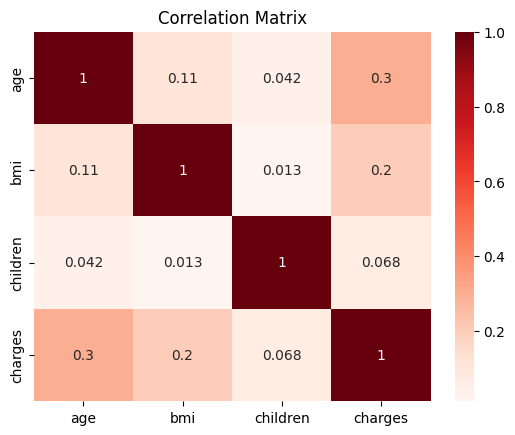

In [39]:
sns.heatmap(medical_df_corr, cmap = "Reds", annot = True)
plt.title("Correlation Matrix");

## 4. Implement Custom Linear Regression Model and a Loss Function

In [40]:
non_smoker_df = medical_df[medical_df["smoker"] == "no"]
#non_smoker_df

<Axes: xlabel='age', ylabel='charges'>

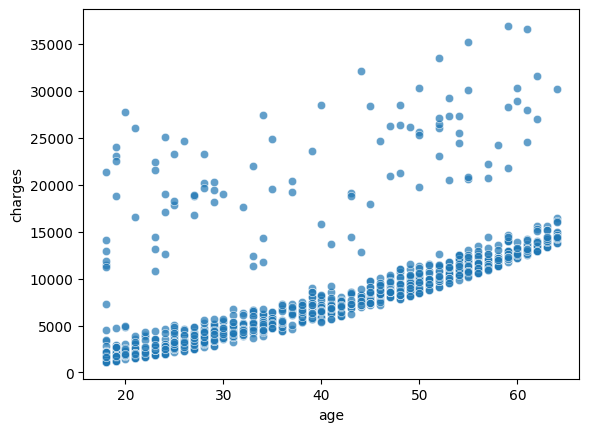

In [41]:
sns.scatterplot(data = non_smoker_df, x = "age", y = "charges", alpha = 0.7,)

In [42]:
# Try this linear model: charges = w * age + b (y = w*x + b)
def linear_regression_charges (age, w , b):
    return w*age + b

In [43]:
import numpy as np

def loss_rmse(targets, predictions):
    return np.sqrt(np.mean(np.square(targets - predictions)))

In [44]:
def test_parameters(w, b):
    ages = non_smoker_df["age"]
    target = non_smoker_df["charges"]

    estimated_charges = linear_regression_charges(ages, w, b)

    plt.figure(figsize = (10, 6))

    plt.plot(ages, estimated_charges, "m", alpha = 0.9)
    plt.scatter(ages, target, s = 8, alpha = 0.8)

    plt.xlabel("Ages")
    plt.ylabel("Charges")
    plt.legend(["Estimated", "Actual"])
    plt.show()

    loss = loss_rmse(target, estimated_charges)
    print(loss)

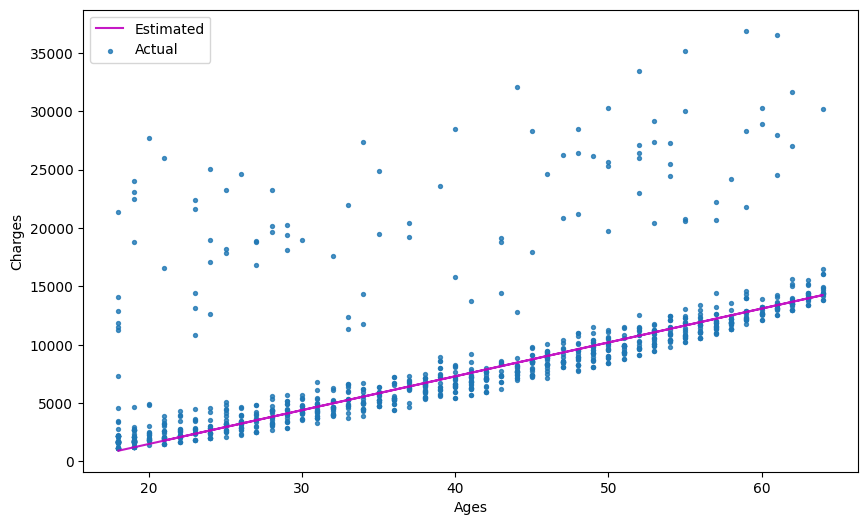

4854.300894122933


In [45]:
test_parameters(290, -4300)

## 5. Simple Linear Regression Model using Scikit-learn Library

In [46]:
from sklearn.linear_model import LinearRegression

In [47]:
model = LinearRegression()

In [48]:
inputs = non_smoker_df[["age"]]
targets = non_smoker_df["charges"]

inputs.shape, targets.shape

((1064, 1), (1064,))

In [49]:
model.fit(inputs, targets)

LinearRegression()

In [50]:
predictions = model.predict(inputs)
predictions

array([2719.0598744 , 5391.54900271, 6727.79356686, ..., 2719.0598744 ,
       2719.0598744 , 3520.80661289])

In [51]:
loss_rmse(targets, predictions)

np.float64(4662.505766636395)

In [52]:
model.coef_, model.intercept_

(array([267.24891283]), np.float64(-2091.4205565650864))

## 6. Turn Categorical Data into Numerical

In [53]:
smokers_df = medical_df[medical_df["smoker"] == "yes"]
smokers_df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.9,0,yes,southwest,16884.924
11,62,female,26.29,0,yes,southeast,27808.7251
14,27,male,42.13,0,yes,southeast,39611.7577
19,30,male,35.3,0,yes,southwest,36837.467
23,34,female,31.92,1,yes,northeast,37701.8768
...,...,...,...,...,...,...,...
1313,19,female,34.7,2,yes,southwest,36397.576
1314,30,female,23.655,3,yes,northwest,18765.87545
1321,62,male,26.695,0,yes,northeast,28101.33305
1323,42,female,40.37,2,yes,southeast,43896.3763


<Axes: xlabel='age', ylabel='charges'>

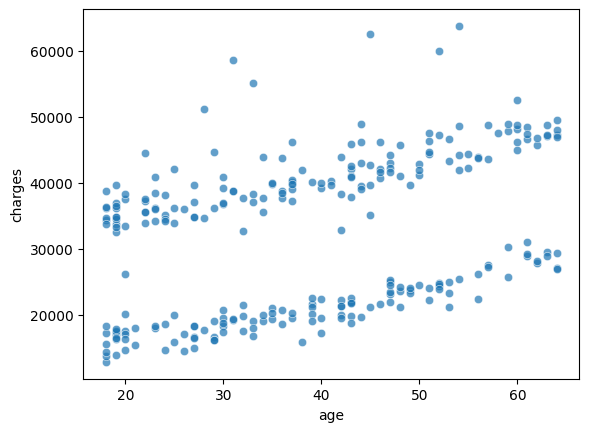

In [54]:
sns.scatterplot(data = smokers_df, x = "age", y = "charges", alpha = 0.7,)

In [55]:
input_smokers = smokers_df[["age"]]
target_smokers = smokers_df["charges"]

model_smokers = LinearRegression()
model_smokers.fit(input_smokers, target_smokers)

LinearRegression()

In [56]:
predictions_smokers = model_smokers.predict(input_smokers)
loss_smokers = loss_rmse(target_smokers, predictions_smokers)
print(loss_smokers)

10711.00334810241


In [57]:
inputs, targets = non_smoker_df[["age", "bmi"]], non_smoker_df["charges"]

model = LinearRegression().fit(inputs, targets)
model_predictions = model.predict(inputs)

loss = loss_rmse(targets, model_predictions)
loss

np.float64(4662.3128354612945)

In [58]:
non_smoker_df["charges"].corr(non_smoker_df.bmi)

np.float64(0.0840365431283327)

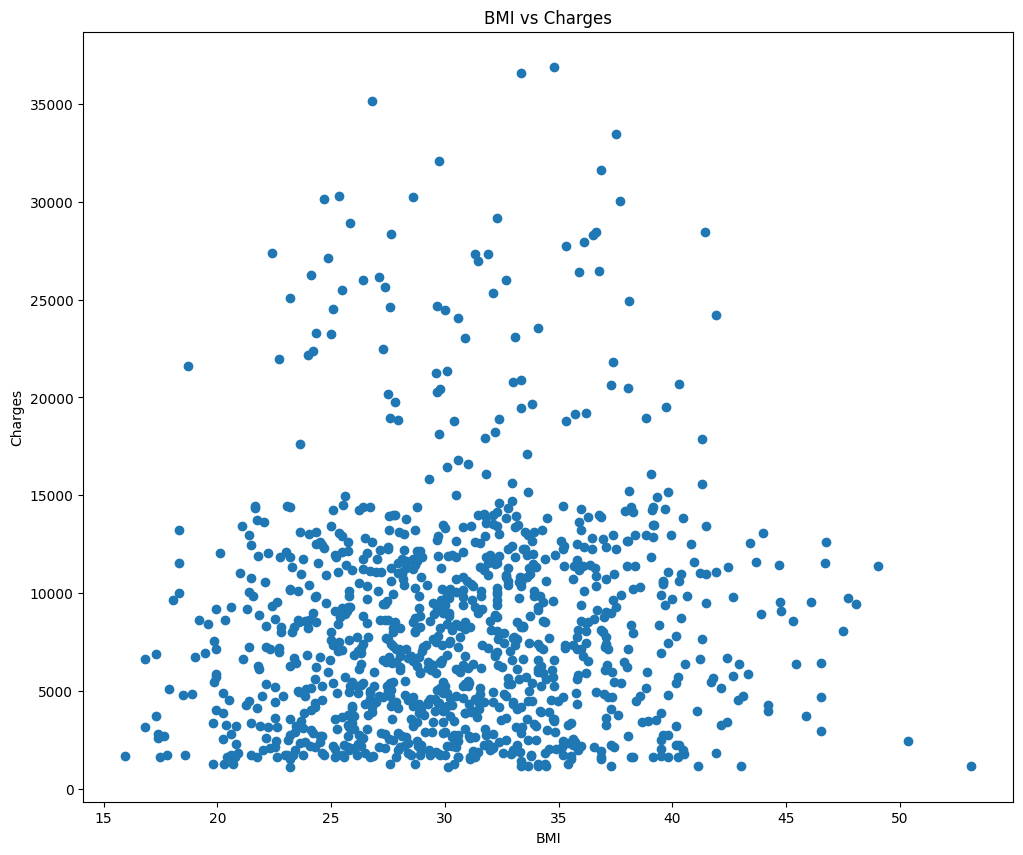

In [59]:
plt.figure(figsize = (12, 10))

plt.scatter(x = non_smoker_df["bmi"], y = non_smoker_df["charges"],)

plt.xlabel("BMI")
plt.ylabel("Charges")
plt.title("BMI vs Charges")
plt.show()

In [60]:
model.coef_, model.intercept_

(array([266.87657817,   7.07547666]), np.float64(-2293.6320906488727))

In [61]:
# Train bmi vs charges

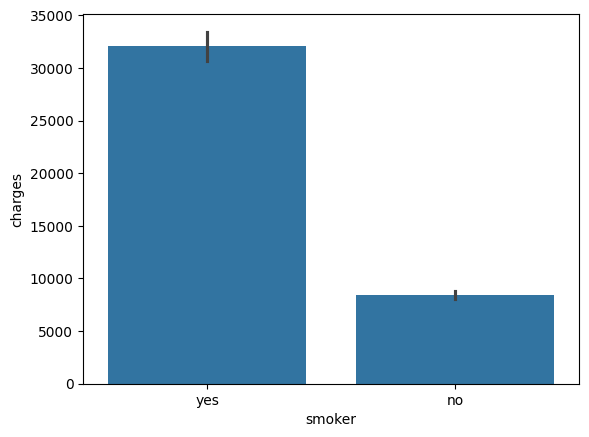

In [62]:
sns.barplot(data = medical_df, x = "smoker", y = "charges");

In [63]:
smoker_numerical = {"no": 0, "yes": 1}
medical_df.insert(loc = 5, column = "smoker_numerical", value = medical_df["smoker"].map(smoker_numerical))
#medical_df["smoker_numerical"] = medical_df["smoker"].map(smoker_numerical)

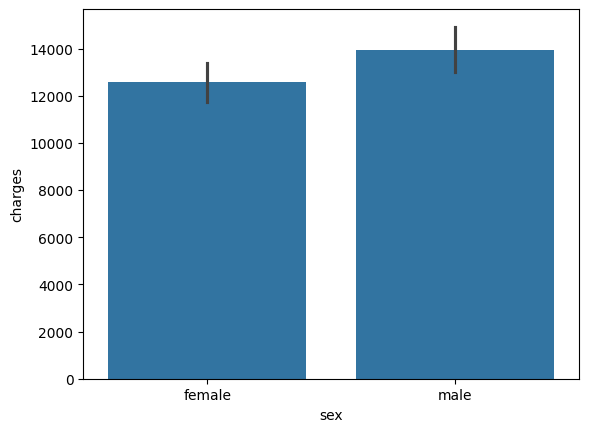

In [64]:
sns.barplot(data = medical_df, x = "sex", y = "charges");

In [65]:
sex_numerical = {"female": 0 , "male": 1}
medical_df.insert(loc = 2, column = "sex_numerical", value = medical_df["sex"].map(sex_numerical))

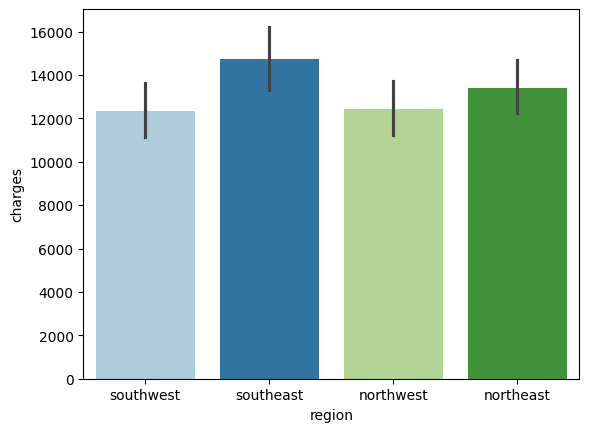

In [66]:
sns.barplot(data = medical_df, x = "region", y = "charges", hue = "region", palette = "Paired", legend = False);

In [67]:
from sklearn import preprocessing

enc = preprocessing.OneHotEncoder()
enc.fit(medical_df[["region"]])
categories_region = enc.categories_[0]
categories_region

array(['northeast', 'northwest', 'southeast', 'southwest'], dtype=object)

In [68]:
# Test Function
enc.transform(pd.DataFrame([["northeast"]], columns=["region"])).toarray()

array([[1., 0., 0., 0.]])

In [69]:
one_hot = enc.transform(medical_df[["region"]]).toarray()

In [70]:
df_enc = pd.DataFrame(data = one_hot, columns = categories_region, index = medical_df.index)
medical_df = pd.concat([medical_df, df_enc], axis = 1)

In [71]:
medical_df

,age,sex,sex_numerical,bmi,children,smoker,smoker_numerical,region,charges,northeast,northwest,southeast,southwest
0,19,female,0,27.9,0,yes,1,southwest,16884.924,0.0,0.0,0.0,1.0
1,18,male,1,33.77,1,no,0,southeast,1725.5523,0.0,0.0,1.0,0.0
2,28,male,1,33.0,3,no,0,southeast,4449.462,0.0,0.0,1.0,0.0
3,33,male,1,22.705,0,no,0,northwest,21984.47061,0.0,1.0,0.0,0.0
4,32,male,1,28.88,0,no,0,northwest,3866.8552,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,1,30.97,3,no,0,northwest,10600.5483,0.0,1.0,0.0,0.0
1334,18,female,0,31.92,0,no,0,northeast,2205.9808,1.0,0.0,0.0,0.0
1335,18,female,0,36.85,0,no,0,southeast,1629.8335,0.0,0.0,1.0,0.0
1336,21,female,0,25.8,0,no,0,southwest,2007.945,0.0,0.0,0.0,1.0


In [72]:
input_cols = ["age", "sex_numerical", "bmi", "children", "smoker_numerical",
              "northeast", "northwest", "southeast", "southwest"]
inputs, targets = medical_df[input_cols], medical_df["charges"]

model = LinearRegression().fit(inputs, targets)
predictions =  model.predict(inputs)

loss = loss_rmse(targets, predictions)
loss

np.float64(6041.6796511744515)

In [73]:
medical_df[input_cols]

,age,sex_numerical,bmi,children,smoker_numerical,northeast,northwest,southeast,southwest
0,19,0,27.9,0,1,0.0,0.0,0.0,1.0
1,18,1,33.77,1,0,0.0,0.0,1.0,0.0
2,28,1,33.0,3,0,0.0,0.0,1.0,0.0
3,33,1,22.705,0,0,0.0,1.0,0.0,0.0
4,32,1,28.88,0,0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
1333,50,1,30.97,3,0,0.0,1.0,0.0,0.0
1334,18,0,31.92,0,0,1.0,0.0,0.0,0.0
1335,18,0,36.85,0,0,0.0,0.0,1.0,0.0
1336,21,0,25.8,0,0,0.0,0.0,0.0,1.0


## 7. Divide the Data into Train and Test Split

In [74]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(inputs, targets, test_size=0.1)

In [75]:
# Create and train the model
model = LinearRegression().fit(X_train, y_train)

# Generate predictions
predictions_test = model.predict(X_test)

# Compute loss to evalute the model
loss = loss_rmse(y_test, predictions_test)
print('Test Loss:', loss)

Test Loss: 5697.883160907368


In [76]:
# Generate predictions
predictions_train = model.predict(X_train)

# Compute loss to evalute the model
loss = loss_rmse(y_train, predictions_train)
print('Training Loss:', loss)

Training Loss: 6080.679287721826


## 8. Linear Models for Smoking and Non-Smoking People

### 8.1 People that smoke (smoker)

In [77]:
medical_df

,age,sex,sex_numerical,bmi,children,smoker,smoker_numerical,region,charges,northeast,northwest,southeast,southwest
0,19,female,0,27.9,0,yes,1,southwest,16884.924,0.0,0.0,0.0,1.0
1,18,male,1,33.77,1,no,0,southeast,1725.5523,0.0,0.0,1.0,0.0
2,28,male,1,33.0,3,no,0,southeast,4449.462,0.0,0.0,1.0,0.0
3,33,male,1,22.705,0,no,0,northwest,21984.47061,0.0,1.0,0.0,0.0
4,32,male,1,28.88,0,no,0,northwest,3866.8552,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,1,30.97,3,no,0,northwest,10600.5483,0.0,1.0,0.0,0.0
1334,18,female,0,31.92,0,no,0,northeast,2205.9808,1.0,0.0,0.0,0.0
1335,18,female,0,36.85,0,no,0,southeast,1629.8335,0.0,0.0,1.0,0.0
1336,21,female,0,25.8,0,no,0,southwest,2007.945,0.0,0.0,0.0,1.0


In [78]:
df_smoker = medical_df[medical_df["smoker"] == "yes"]

In [79]:
df_smoker

,age,sex,sex_numerical,bmi,children,smoker,smoker_numerical,region,charges,northeast,northwest,southeast,southwest
0,19,female,0,27.9,0,yes,1,southwest,16884.924,0.0,0.0,0.0,1.0
11,62,female,0,26.29,0,yes,1,southeast,27808.7251,0.0,0.0,1.0,0.0
14,27,male,1,42.13,0,yes,1,southeast,39611.7577,0.0,0.0,1.0,0.0
19,30,male,1,35.3,0,yes,1,southwest,36837.467,0.0,0.0,0.0,1.0
23,34,female,0,31.92,1,yes,1,northeast,37701.8768,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1313,19,female,0,34.7,2,yes,1,southwest,36397.576,0.0,0.0,0.0,1.0
1314,30,female,0,23.655,3,yes,1,northwest,18765.87545,0.0,1.0,0.0,0.0
1321,62,male,1,26.695,0,yes,1,northeast,28101.33305,1.0,0.0,0.0,0.0
1323,42,female,0,40.37,2,yes,1,southeast,43896.3763,0.0,0.0,1.0,0.0


In [88]:
inputs_cols = ["age", "sex_numerical", "bmi", "children", "northeast",
              "northwest", "southeast", "southwest"]
inputs = df_smoker[inputs_cols]
targets = df_smoker["charges"]
#inputs, targets

,charges
0,16884.924
11,27808.7251
14,39611.7577
19,36837.467
23,37701.8768
...,...
1313,36397.576
1314,18765.87545
1321,28101.33305
1323,43896.3763


In [89]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(inputs)

scaled_input = scaler.transform(inputs)
scaled_input

array([[-1.40415473, -1.17584382, -0.4452835 , ..., -0.51818773,
        -0.70517215,  1.92980256],
       [ 1.68987015, -1.17584382, -0.70055124, ..., -0.51818773,
         1.41809344, -0.51818773],
       [-0.82852219,  0.85045308,  1.81090288, ..., -0.51818773,
         1.41809344, -0.51818773],
       ...,
       [ 1.68987015,  0.85045308, -0.63633793, ..., -0.51818773,
        -0.70517215, -0.51818773],
       [ 0.25078881, -1.17584382,  1.53185242, ..., -0.51818773,
         1.41809344, -0.51818773],
       [ 1.61791608, -1.17584382, -0.25977836, ...,  1.92980256,
        -0.70517215, -0.51818773]])

In [93]:
model_smoker = LinearRegression().fit(scaled_input, targets)
predictions = model_smoker.predict(scaled_input)

loss = loss_rmse(targets, predictions)
loss

np.float64(5668.4678821121515)

In [164]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(inputs, targets, test_size=0.1)     # Test with scaled_input

In [165]:
model_smoker_2 = LinearRegression().fit(X_train, y_train)
predictions_test = model_smoker_2.predict(X_test)
predictions_train = model_smoker_2.predict(X_train)

loss_train = loss_rmse(y_train, predictions_train)
loss_test = loss_rmse(y_test, predictions_test)

print(f"Train loss: {loss_train}, Test Loss: {loss_test}")

Train loss: 5430.77602721368, Test Loss: 7542.812928306577


In [ ]:
# 4191

### 8.2 People that do not smoke (non-smoker)

In [168]:
df_non_smoker = medical_df[medical_df["smoker"] == "no"]

In [169]:
df_non_smoker

,age,sex,sex_numerical,bmi,children,smoker,smoker_numerical,region,charges,northeast,northwest,southeast,southwest
1,18,male,1,33.77,1,no,0,southeast,1725.5523,0.0,0.0,1.0,0.0
2,28,male,1,33.0,3,no,0,southeast,4449.462,0.0,0.0,1.0,0.0
3,33,male,1,22.705,0,no,0,northwest,21984.47061,0.0,1.0,0.0,0.0
4,32,male,1,28.88,0,no,0,northwest,3866.8552,0.0,1.0,0.0,0.0
5,31,female,0,25.74,0,no,0,southeast,3756.6216,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1332,52,female,0,44.7,3,no,0,southwest,11411.685,0.0,0.0,0.0,1.0
1333,50,male,1,30.97,3,no,0,northwest,10600.5483,0.0,1.0,0.0,0.0
1334,18,female,0,31.92,0,no,0,northeast,2205.9808,1.0,0.0,0.0,0.0
1335,18,female,0,36.85,0,no,0,southeast,1629.8335,0.0,0.0,1.0,0.0


In [170]:
inputs_cols = ["age", "sex_numerical", "bmi", "children", "northeast",
              "northwest", "southeast", "southwest"]
inputs = df_non_smoker[inputs_cols]
targets = df_non_smoker["charges"]
#inputs, targets

In [171]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(inputs)

scaled_input = scaler.transform(inputs)
scaled_input

array([[-1.51919137,  1.02860443,  0.51623593, ..., -0.57879726,
         1.70218562, -0.57879726],
       [-0.80880216,  1.02860443,  0.38875821, ..., -0.57879726,
         1.70218562, -0.57879726],
       [-0.45360755,  1.02860443, -1.31563554, ...,  1.72772067,
        -0.58747999, -0.57879726],
       ...,
       [-1.51919137, -0.97219103,  0.20995828, ..., -0.57879726,
        -0.58747999, -0.57879726],
       [-1.51919137, -0.97219103,  1.02614684, ..., -0.57879726,
         1.70218562, -0.57879726],
       [-1.3060746 , -0.97219103, -0.80324131, ..., -0.57879726,
        -0.58747999,  1.72772067]])

In [172]:
model_non_smoker = LinearRegression().fit(scaled_input, targets)
predictions = model_non_smoker.predict(scaled_input)

loss = loss_rmse(targets, predictions)
loss

np.float64(4573.074988795492)

In [225]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(inputs, targets, test_size=0.1)     # Test with scaled_input

In [226]:
model_non_smoker_2 = LinearRegression().fit(X_train, y_train)
predictions_test = model_non_smoker_2.predict(X_test)
predictions_train = model_non_smoker_2.predict(X_train)

loss_train = loss_rmse(y_train, predictions_train)
loss_test = loss_rmse(y_test, predictions_test)

print(f"Train loss: {loss_train}, Test Loss: {loss_test}")

Train loss: 4356.111824086249, Test Loss: 6210.586972074138
